# Imports

In [ ]:
!pip install easydict matplotlib tqdm
!pip install kagglehub==1.0.1

In [1]:
import easydict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.autograd.variable import Variable

import torchvision
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
plt.ion();

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# [Vanilla GAN - 2014](https://github.com/ozanciga/gans-with-pytorch/blob/master/gan/gan.py)

## Generative Adversarial Networks
GAN은 단순히 특정한 이미지를 이해하고 분류하는 것을 넘어서 실제 데이터와 흡사한 가짜 데이터를 생성하는 알고리즘입니다.  GAN은 생성자(Generator) 모델과 구분자(Discriminator) 모델로 두 개의 모델이 학습하는 방식으로 동작합니다.    

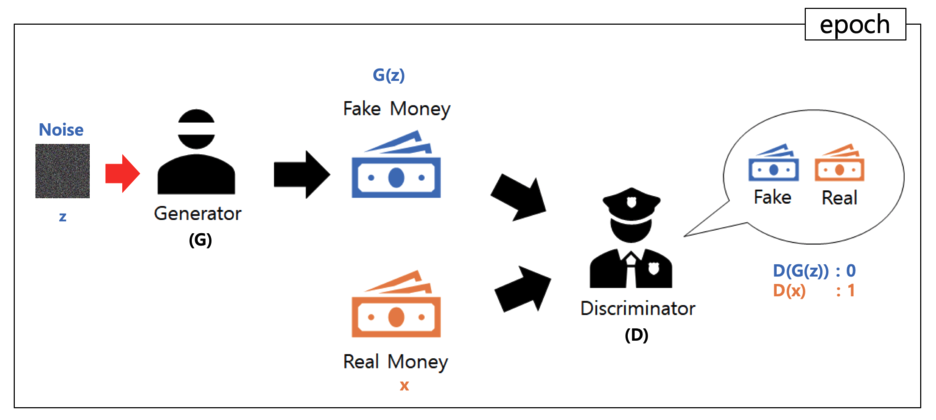

### GAN 학습 과정
1. 구분자 모델은 먼저 진짜 데이터를 진짜로 분류하도록 학습시킵니다.
2. 다음으로 생성자 모델이 생성한 데이터를 가짜로 분류하도록 학습시킵니다.  
3. 마지막으로 학습된 구분자 모델을 속이는 방향으로 생성자 모델을 학습시킵니다.

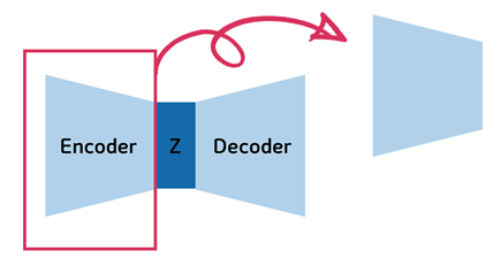

Encoder 부분이 Discriminator 부분이며, Decoder 부분이 Generator가 되는 구조이다.  
- 따라서 Generator는 이미 압축된 저차원의 latent variable의 z가 Generator 네트워크를 통과하게 되면 이미지가 나오게 된다. -> 복원이 되는 것!
- 그러면 방금 복원된 가짜 이미지랑 진짜 이미지(x)가 discriminator network로 들어간다.
- 이때 D(x)라는 것은 진짜 이미지가 들어간 것이고, D(G(z))는 만들어진 가짜 이미지가 들어간 것이다.
- Discriminator의 output이 1이면 real, 0이면 fake라고 예측을 한 것이다.
- 즉 Discriminator가 정확하다면 D(x)는 항상 1이어야하고 D(G(z))는 항상 0이라고 답해야 합니다. -> 그게 Discriminator 목적!

## GAN 모델 구조
- Generator: 가짜 사진을 만드는 네트워크
- Discriminator: 진짜와 가짜를 구분할 수 있는 네트워크

이 두가지 네트워크가 서로 경쟁하는 구조이다.

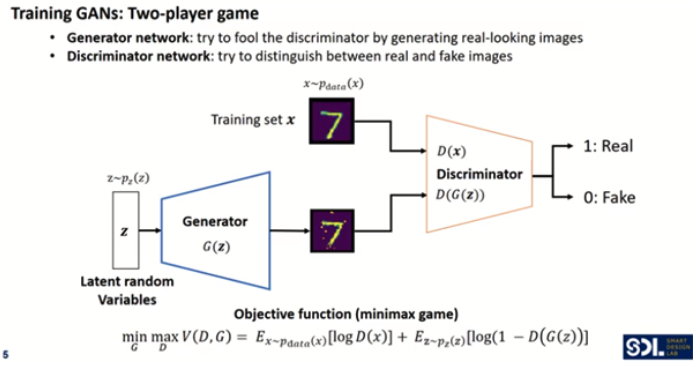

### Objective function / loss function

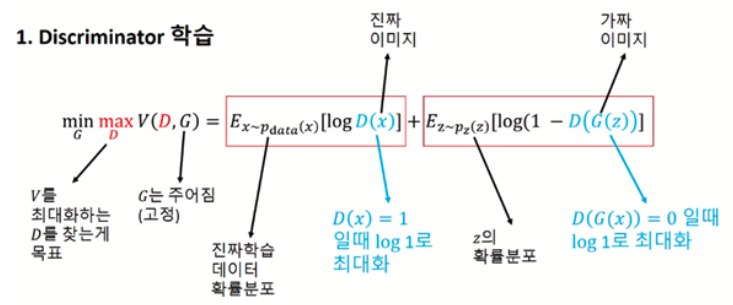

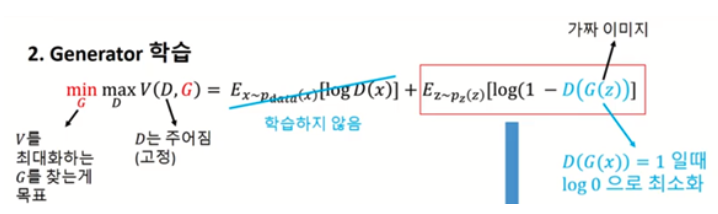

## Model

In [ ]:
opt = easydict.EasyDict()
opt.n_epochs = 100
opt.batch_size = 64
opt.lr = 0.0002
opt.b1 = 0.5
opt.b2 = 0.999
opt.latent_dim = 100
opt.img_size = 28
opt.channels = 1
opt.sample_interval = 512

In [ ]:
img_dims = (opt.channels, opt.img_size, opt.img_size)
n_features = opt.channels * opt.img_size * opt.img_size

img_dims, n_features

((1, 28, 28), 784)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        def ganlayer(n_input, n_output, dropout=True):
            pipeline = [nn.Linear(n_input, n_output)]
            pipeline.append(nn.LeakyReLU(0.2, inplace=True))
            if dropout:
                pipeline.append(nn.Dropout(0.25))
            return pipeline

        self.model = nn.Sequential(
            *ganlayer(opt.latent_dim, 128, dropout=False),
            *ganlayer(128, 256),
            *ganlayer(256, 512),
            *ganlayer(512, 1024),
            nn.Linear(1024, n_features),
            nn.Tanh()
        )
        # Tanh > Image values are between [-1, 1]

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), *img_dims)
        return img

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        flatimg = img.view(img.size(0), -1)
        prob = self.model( flatimg )
        return prob

## MNIST Data

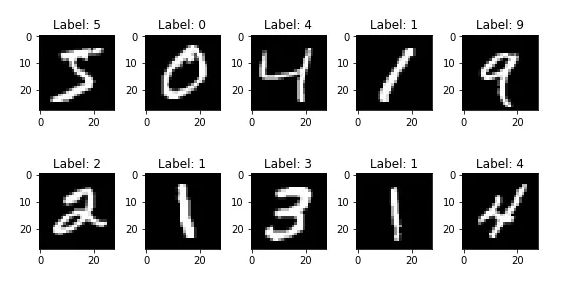

In [ ]:
def mnist_data():
    compose = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5), (0.5))
         ])
    output_dir = './data/mnist'
    return datasets.MNIST(root=output_dir, train=True,
                          transform=compose, download=True)

In [ ]:
mnist = mnist_data()
batch_iterator = DataLoader(mnist, shuffle=True, batch_size=opt.batch_size) # List, NCHW format.

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 9912422/9912422 [00:11<00:00, 894414.80it/s] 


Extracting ./data/mnist/MNIST/raw/train-images-idx3-ubyte.gz to ./data/mnist/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 28881/28881 [00:00<00:00, 133594.30it/s]


Extracting ./data/mnist/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/mnist/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 1648877/1648877 [00:01<00:00, 1258052.39it/s]


Extracting ./data/mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/mnist/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 4542/4542 [00:00<00:00, 6553329.47it/s]

Extracting ./data/mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/mnist/MNIST/raw



In [ ]:
images, targets = next(iter(batch_iterator))

images.shape, targets.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

## Train

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# 2진 분류 loss function
gan_loss = nn.BCELoss()

# 생성형 모델 -> 렌덤 데이터를 이용하여 가짜 이미지를 생성 task
generator = Generator().to(device)
# 판단하는 모델 -> 가짜 이미지와 진짜 이미지를 구분하는 task
discriminator = Discriminator().to(device)

# 판단하는 모델용
optimizer_D = optim.Adam(discriminator.parameters(), lr=opt.lr, betas=(opt.b1, opt.b2))
# 생성하는 모델용
optimizer_G = optim.Adam(generator.parameters(), lr=opt.lr, betas=(opt.b1, opt.b2))

# DataLoader 생성
batch_iterator = DataLoader(mnist, shuffle=True, batch_size=opt.batch_size)

In [ ]:
g_losses = [] # 생성형 모델 loss
d_losses = [] # 판단형 모델 loss

# epoch가 40일때 마다 이미지를 그려줄 때 사용하는 input 렌덤 데이터(=5개)
testing_random_latent = torch.randn(5, opt.latent_dim).normal_(0, 1).to(device)

testing_random_latent.shape

torch.Size([5, 100])

epoch:   0%|          | 0/200 [00:00<?, ?it/s]

EPOCH 0: BATCH: 937, discrim_loss: 0.7283435463905334, generator_loss: 1.038888692855835


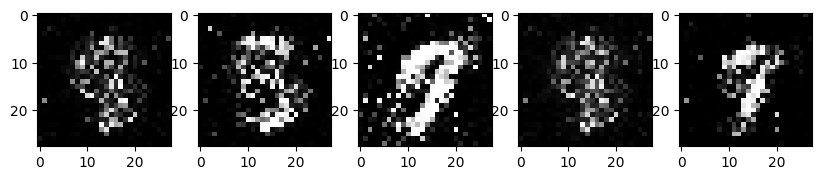

In [ ]:
from tqdm.auto import tqdm

for epoch in tqdm(range(opt.n_epochs), desc="epoch"):

    # images -> (batch, color, height, width)
    for batch_index, (images, _) in enumerate(batch_iterator):

        ###################################################
        # Target 데이터 생성
        ###################################################
        # real -> (batch_size, 1(=1))
        real = torch.ones(images.size(0), 1, requires_grad=False).to(device)
        # fake -> (batch_size, 1(=0))
        fake = torch.zeros(images.size(0), 1, requires_grad=False).to(device)

        real.shape, fake.shape

        ###################################################
        # == Discriminator Model == #
        ###################################################
        # 진짜 이미지 데이터
        imgs_real = images.to(device)
        # 렌덤 데이터
        noise = torch.randn(images.size(0), opt.latent_dim).normal_(0, 1).to(device)
        # 레덤 데이터를 이용하여 생성형 모델이 만든 가짜 이미지 데이터
        imgs_fake = Variable(generator(noise), requires_grad=False)

        # 모델 학습
        # 판단하는 모델이 진짜 이미지를 판단함
        d_real_pred = discriminator(imgs_real)
        # 판단하는 모델이 가짜 이미지를 판단함
        d_fake_pred = discriminator(imgs_fake)

        # loss 계산
        # 판단하는 모델 loss -> 진짜 이미지 예측 loss + 가짜 이미지 예측 loss
        d_loss = gan_loss(d_real_pred, real) + \
                 gan_loss(d_fake_pred, fake)

        # 역전파
        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        ###################################################
        # == Generator Model == #
        ###################################################

        # feature 데이터 생성
        noise = torch.randn(images.size(0), opt.latent_dim).normal_(0, 1).to(device)

        # 모델 학습
        imgs_fake = generator(noise)

        # loss 계산
        # 판단하는 모델을 얼마나 속였는지 loss 계산
        d_fake_pred = discriminator(imgs_fake)
        g_loss = gan_loss(d_fake_pred, real)

        # 역전파
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        ###################################################
        # == loss update == #
        ###################################################
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())


    ###################################################
    # epoch 40번에 한번씩 가짜 이미지를 print
    ###################################################
    if epoch % 40 == 0:
        print("EPOCH {}: BATCH: {}, discrim_loss: {}, generator_loss: {}".format(epoch, batch_index, d_loss, g_loss))
        with torch.no_grad():
            testing_fake_images = generator(testing_random_latent)
            testing_fake_images = testing_fake_images.reshape(5, 28, 28).cpu().numpy()

            plt.figure(figsize=(10, 5))
            # plt.title("GENERATED IMAGE, EPOCH {}".format(epoch))
            for i in range(5):
                plt.subplot(int('15{}'.format(i+1)))
                plt.imshow(testing_fake_images[i], cmap='gray')
            plt.show()

# [CGAN - 2014](https://github.com/ozanciga/gans-with-pytorch/blob/master/cgan/cgan.py)

## Conditional GAN
- CGAN은 생성자와 판별자가 훈련하는 동안 추가 정보를 사용해 조건이 붙는 생성적 적대 신경망입니다.
- CGAN을 이용하면 우리가 원하는 class가 담긴 데이터를 생성할 수 있습니다.
- 생성자와 판별자를 훈련하는 데 모두 label을 사용합니다.

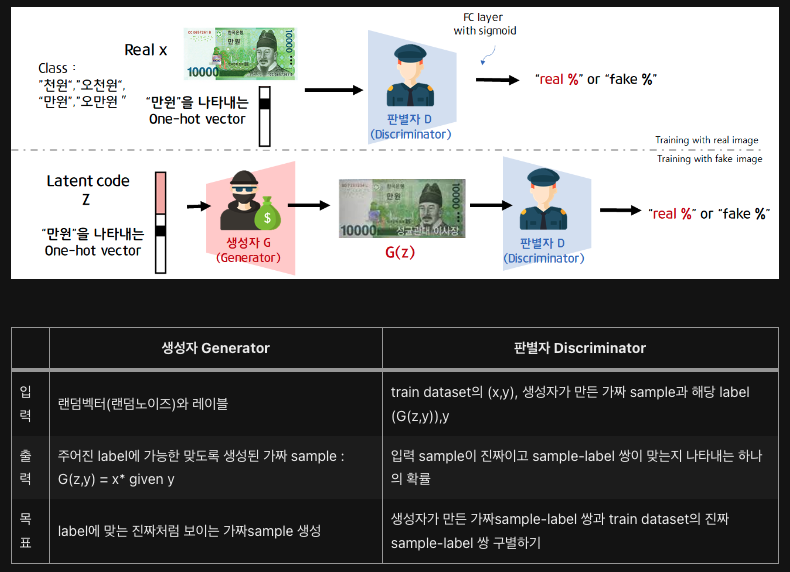

## CGAN 모델 구조

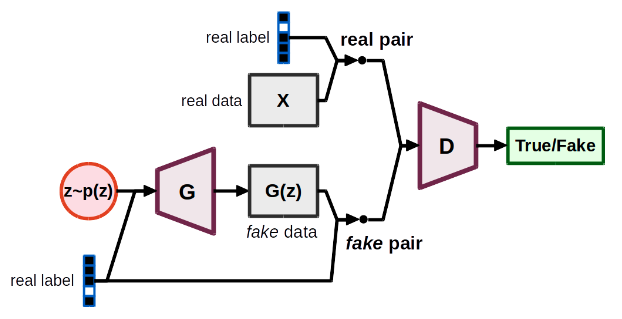

## Model

In [3]:
opt = easydict.EasyDict()
opt.n_epochs = 400
opt.batch_size = 100
opt.lr = 0.0002
opt.b1 = 0.5
opt.b2 = 0.999
opt.latent_dim = 100
opt.img_size = 28
opt.channels = 1
opt.n_classes = 10
opt.sample_interval = 512

In [7]:
img_dims = (opt.channels, opt.img_size, opt.img_size)
n_features = opt.channels * opt.img_size * opt.img_size

n_features, img_dims

(784, (1, 28, 28))

In [8]:
def weights_init_xavier(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.xavier_normal_(m.weight.data, gain=0.02)
    elif classname.find('Linear') != -1:
        nn.init.xavier_normal_(m.weight.data, gain=0.02)
    elif classname.find('BatchNorm1d') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)

In [9]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # Map z & y (noise and label) into the hidden layer.
        # TO DO: How to run this with a function defined here?
        self.z_map = nn.Sequential(
            nn.Linear(opt.latent_dim, 200),
            nn.BatchNorm1d(200),
            nn.ReLU(inplace=True),
        )
        self.y_map = nn.Sequential(
            nn.Linear(opt.n_classes, 1000),
            nn.BatchNorm1d(1000),
            nn.ReLU(inplace=True),
        )
        self.zy_map = nn.Sequential(
            nn.Linear(1200, 1200),
            nn.BatchNorm1d(1200),
            nn.ReLU(inplace=True),
        )

        self.model = nn.Sequential(
            nn.Linear(1200, n_features),
            nn.Tanh()
        )
        # Tanh > Image values are between [-1, 1]


    def forward(self, z, y): # z: features / y: targets
        # zh -> features 학습 결과
        zh = self.z_map(z)
        # yh -> targets 학습 결과
        yh = self.y_map(y)

        # zy -> zh + yh -> features 학습 결과 + targets 학습 결과
        zy = torch.cat((zh, yh), dim=1) # Combine noise and labels.
        # zhy -> zy 학습 결과
        zyh = self.zy_map(zy)
        # zyh를 이용해서 targets을 예측
        x = self.model(zyh)
        x = x.view(x.size(0), *img_dims)
        return x

In [10]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(240, 1),
            nn.Sigmoid()
        )

        # Imitating a 3d array by combining second and third dimensions via multiplication for maxout.
        self.x_map = nn.Sequential(nn.Linear(n_features, 240 * 5))
        self.y_map = nn.Sequential(nn.Linear(opt.n_classes, 50 * 5))
        self.j_map = nn.Sequential(nn.Linear(240 + 50, 240 * 4))

    def forward(self, x, y): # x -> features & y -> targets
        # maxout for x
        x = x.view(-1, n_features)
        x = self.x_map(x)
        x, _ = x.view(-1, 240, 5).max(dim=2) # pytorch outputs max values and indices
        # .. and y
        y = y.view(-1, opt.n_classes)
        y = self.y_map(y)
        y, _ = y.view(-1, 50, 5).max(dim=2)
        # joint maxout layer
        jmx = torch.cat((x, y), dim=1)
        jmx = self.j_map(jmx)
        jmx, _ = jmx.view(-1, 240, 4).max(dim=2)

        prob = self.model(jmx)
        return prob

## MNIST Data

In [11]:
def mnist_data():
    compose = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5), (0.5))
         ])
    output_dir = './data/mnist'
    return datasets.MNIST(root=output_dir, train=True,
                          transform=compose, download=True)

In [12]:
mnist = mnist_data()
batch_iterator = DataLoader(mnist, shuffle=True, batch_size=opt.batch_size) # List, NCHW format.

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 9912422/9912422 [00:00<00:00, 17824802.97it/s]


Extracting ./data/mnist/MNIST/raw/train-images-idx3-ubyte.gz to ./data/mnist/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 28881/28881 [00:00<00:00, 492247.43it/s]


Extracting ./data/mnist/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/mnist/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 1648877/1648877 [00:00<00:00, 4479346.43it/s]


Extracting ./data/mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/mnist/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 4542/4542 [00:00<00:00, 6072849.46it/s]

Extracting ./data/mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/mnist/MNIST/raw



## Train

In [13]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Weight initialization.
generator.apply(weights_init_xavier)
discriminator.apply(weights_init_xavier)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=240, out_features=1, bias=True)
    (1): Sigmoid()
  )
  (x_map): Sequential(
    (0): Linear(in_features=784, out_features=1200, bias=True)
  )
  (y_map): Sequential(
    (0): Linear(in_features=10, out_features=250, bias=True)
  )
  (j_map): Sequential(
    (0): Linear(in_features=290, out_features=960, bias=True)
  )
)

In [14]:
gan_loss = nn.BCELoss()

optimizer_D = optim.Adam(discriminator.parameters(), lr=opt.lr, betas=(opt.b1, opt.b2))
optimizer_G = optim.Adam(generator.parameters(), lr=opt.lr, betas=(opt.b1, opt.b2))

  0%|          | 0/400 [00:00<?, ?it/s]

EPOCH 0: BATCH: 599, discrim_loss: 1.3235045671463013, generator_loss: 0.6969894766807556
labels: [8, 8, 4, 9, 8]


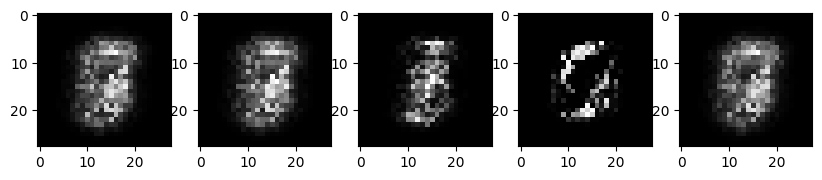

EPOCH 40: BATCH: 599, discrim_loss: 0.7433414459228516, generator_loss: 2.2927048206329346
labels: [3, 2, 2, 0, 7]


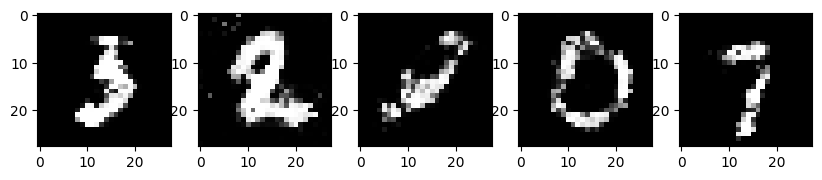

EPOCH 80: BATCH: 599, discrim_loss: 0.9212857484817505, generator_loss: 1.691089391708374
labels: [0, 5, 6, 7, 7]


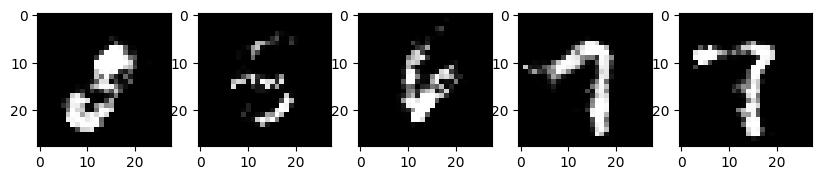

KeyboardInterrupt: 

In [15]:
from tqdm.auto import tqdm

g_losses = []
d_losses = []
testing_random_latent = torch.randn(5, opt.latent_dim).normal_(0, 1).to(device)

for epoch in tqdm(range(opt.n_epochs)):
    for batch_index, (batch, labels) in enumerate(batch_iterator):

        ############################################
        # target 생성
        ############################################
        real = torch.ones(batch.size(0), 1, requires_grad=False).to(device)
        fake = torch.zeros(batch.size(0), 1, requires_grad=False).to(device)

        ############################################
        # input data 생성
        ############################################
        labels_onehot = torch.zeros(batch.size(0), opt.n_classes).to(device)
        labels_ = labels.long().to(device) # Note: MNIST dataset is given as a longtensor, and we use .type() to feed it into cuda (if cuda available).
        labels_ = labels_.view(batch.size(0), 1)
        labels_onehot = labels_onehot.scatter_(1, labels_, 1) # As of 0.4, we don't have one-hot built-in function yet in pytorch.

        imgs_real = batch.to(device)
        noise = torch.randn(batch.size(0), opt.latent_dim).normal_(0, 1).to(device)
        imgs_fake = generator(noise, labels_onehot)

        ############################################
        # == Discriminator update == #
        ############################################
        # 모델 학습
        d_real_pred = discriminator(imgs_real, labels_onehot)
        d_fake_pred = discriminator(imgs_fake, labels_onehot)

        # loss 계산
        d_loss = gan_loss(d_real_pred, real) + \
                 gan_loss(d_fake_pred, fake)

        # 역전파
        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        ############################################
        # == Generator update == #
        ############################################
        # input data
        noise = torch.randn(batch.size(0), opt.latent_dim).normal_(0, 1).to(device)

        # 모델 학습
        imgs_fake = generator(noise, labels_onehot)

        # loss 계산
        g_loss = gan_loss(discriminator(imgs_fake, labels_onehot), real)

        # 역전파
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        ###################################################
        # == loss update == #
        ###################################################
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    ###################################################
    # epoch 40번에 한번씩 가짜 이미지를 print
    ###################################################
    if epoch % 40 == 0:
        print("EPOCH {}: BATCH: {}, discrim_loss: {}, generator_loss: {}".format(epoch, batch_index, d_loss, g_loss))
        labels = labels_onehot[:5]
        labels_topk = labels.topk(1)[1].reshape(-1).tolist()
        print(f"labels: {labels_topk}")
        with torch.no_grad():
            testing_fake_images = generator(testing_random_latent, labels)
            testing_fake_images = testing_fake_images.reshape(5, 28, 28).cpu().numpy()

            plt.figure(figsize=(10, 5))
            # plt.title("GENERATED IMAGE, EPOCH {}".format(epoch))
            for i in range(5):
                plt.subplot(int('15{}'.format(i+1)))
                plt.imshow(testing_fake_images[i], cmap='gray')
            plt.show()


# [DCGAN - 2015](https://github.com/ozanciga/gans-with-pytorch/blob/master/dcgan/dcgan.py)

## Deep Convolutional GAN
- DCGAN은 CNN 구조로 판별자 D와 생성자 G를 구성한 GAN입니다.
- 판별자 D는 이미지를 입력으로 받아 binary classification을 수행하는 CNN 구조이다.
- 생성자 G는 random vector z를 입력으로 받아 이미지를 생성하는 deconvolutional entwork 구조를 갖게 됩니다.
- DCGAN의 특징으로는 pooling layer를 사용하지 않고 stride 2이상인 convolution, deconvolution을 사용하였습니다.

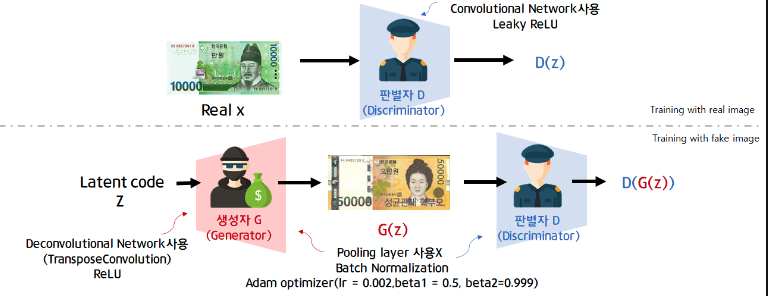

## DCGAN 모델 구조

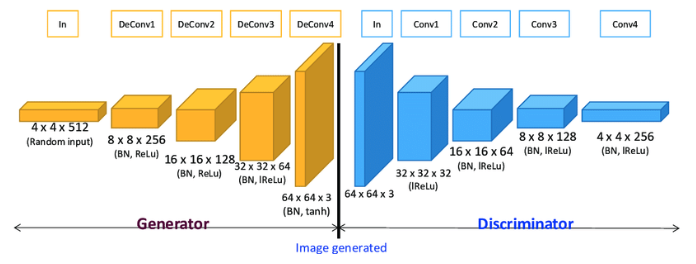

## Model

In [16]:
opt = easydict.EasyDict()
opt.n_epochs = 2000
opt.batch_size = 64
opt.lr = 0.0001
opt.b1 = 0.5
opt.b2 = 0.999
opt.latent_dim = 100
opt.img_size = 32
opt.channels = 3
opt.n_classes = 10
opt.sample_interval = 64

In [17]:
img_dims = (opt.channels, opt.img_size, opt.img_size)
n_features = opt.channels * opt.img_size * opt.img_size

In [18]:
def weights_init_xavier(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 or classname.find('Linear') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

In [19]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        def convlayer(n_input, n_output, k_size=4, stride=2, padding=0):
            block = [
                nn.ConvTranspose2d(n_input, n_output, kernel_size=k_size, stride=stride, padding=padding, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(n_output),
            ]
            return block

        # pytorch doesn't have padding='same' as keras does.
        # hence we have to pad manually to get the desired behavior.
        # from the manual:
        # o = (i−1)∗s−2p+k, i/o = in/out-put, k = kernel size, p = padding, s = stride.

        self.model = nn.Sequential(
            *convlayer(opt.latent_dim, 256, 4, 1, 0), # Fully connected layer via convolution.
            *convlayer(256, 128, 4, 2, 1), # 4->8, (4-1)*2-2p+4 = 8, p = 1
            *convlayer(128, 64, 4, 2, 1), # 8->16, p = 1
            nn.ConvTranspose2d(64, opt.channels, 4, 2, 1),
            nn.Tanh()
        )
        # Tanh > Image values are between [-1, 1]

    def forward(self, z):
        img = self.model(z)
        img = img.view(z.size(0), *img_dims)
        return img

In [20]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        # Again, we must ensure the same padding.
        # From the manual:
        # o = (i+2p−d∗(kernel_size−1)−1)/s+1, d = dilation (default = 1).

        self.model = nn.Sequential(
            nn.Conv2d(opt.channels, 64, 4, 2, 1, bias=False), # 32-> 16, (32+2p-3-1)/2 + 1 = 16, p = 1
            nn.LeakyReLU(0.2, inplace=True),
            # nn.BatchNorm2d(64), # IS IT CRUCIAL TO SKIP BN AT FIRST LAYER OF DISCRIMINATOR?
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False), # FC with Conv.
            nn.Sigmoid()
        )


    def forward(self, img):
        prob = self.model(img)
        return prob

## [CIFAR10 Data](https://www.cs.toronto.edu/~kriz/cifar.html)

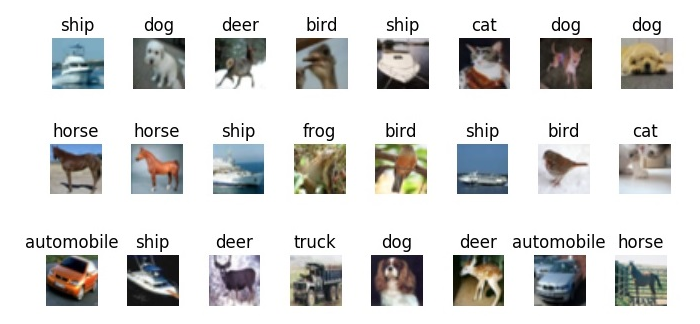

In [21]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [22]:
batch_size = 4

trainset = datasets.CIFAR10(root='./data/cifar10', train=True,
                                        download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

100%|██████████| 170498071/170498071 [00:04<00:00, 37223411.87it/s]


Extracting ./data/cifar10/cifar-10-python.tar.gz to ./data/cifar10


In [23]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [24]:
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    print(f'npimg.shape: {npimg.shape}')
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [25]:
# 학습용 이미지를 무작위로 가져오기
dataiter = iter(trainloader)
images, labels = next(dataiter)

images.shape, labels.shape

(torch.Size([4, 3, 32, 32]), torch.Size([4]))

npimg.shape: (3, 36, 138)


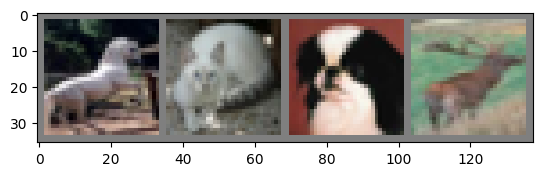

horse cat   dog   deer 


In [26]:
# 이미지 보여주기
imshow(torchvision.utils.make_grid(images))
# 정답(label) 출력
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

### Dataset

In [27]:
def custom_data(CIFAR_CLASS = 5): # Only working with dogs.
    compose = transforms.Compose(
        [transforms.Resize(opt.img_size),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
         ])

    output_dir = './data/cifar10'
    cifar = datasets.CIFAR10(root=output_dir, download=True, train=True,
                          transform=compose)

    features = torch.zeros(5000, 3, 32, 32).to(device)
    targets = torch.zeros(5000, 1).to(device)

    it = 0
    for i in range(cifar.__len__()):
        sample = cifar.__getitem__(i)
        if sample[1] == CIFAR_CLASS:
            features[it, ...] = sample[0]
            targets[it] = sample[1]
            it += 1
    return features, targets

In [28]:
features, targets = custom_data(CIFAR_CLASS=1) # Cars.

Files already downloaded and verified


In [29]:
batch_iterator = DataLoader(torch.utils.data.TensorDataset(features, targets), shuffle=True, batch_size=opt.batch_size) # List, NCHW format.

In [30]:
# 학습용 이미지를 무작위로 가져오기
dataiter = iter(batch_iterator)
images, labels = next(dataiter)

In [31]:
images.shape, labels.shape

(torch.Size([64, 3, 32, 32]), torch.Size([64, 1]))

In [32]:
images_ = images[:5].cpu()
labels_ = labels[:5].squeeze().cpu().tolist()

images_.shape, labels_

(torch.Size([5, 3, 32, 32]), [1.0, 1.0, 1.0, 1.0, 1.0])

npimg.shape: (3, 36, 172)


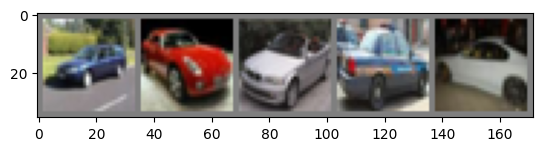

car   car   car   car   car  


In [33]:
# 이미지 보여주기
imshow(torchvision.utils.make_grid(images_))
print(' '.join(f'{classes[int(labels_[j])]:5s}' for j in range(5)))

### DataLoader

In [34]:
batch_iterator = DataLoader(torch.utils.data.TensorDataset(features, targets), shuffle=True, batch_size=opt.batch_size) # List, NCHW format.

## Train

In [35]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

gan_loss = nn.BCELoss()
optimizer_D = optim.Adam(discriminator.parameters(), lr=opt.lr, betas=(opt.b1, opt.b2))
optimizer_G = optim.Adam(generator.parameters(), lr=opt.lr, betas=(opt.b1, opt.b2))

generator.apply(weights_init_xavier)
discriminator.apply(weights_init_xavier)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)

  0%|          | 0/1000 [00:00<?, ?it/s]

EPOCH 0: BATCH: 78, discrim_loss: 0.08033394813537598, generator_loss: 2.690544605255127
npimg.shape: (3, 36, 172)


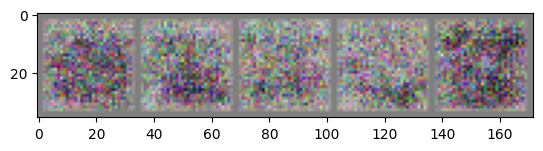

EPOCH 200: BATCH: 78, discrim_loss: 0.34707340598106384, generator_loss: 2.611466884613037
npimg.shape: (3, 36, 172)


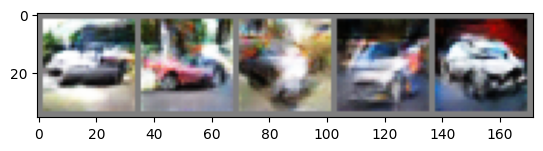

EPOCH 400: BATCH: 78, discrim_loss: 0.09493664652109146, generator_loss: 5.742304801940918
npimg.shape: (3, 36, 172)


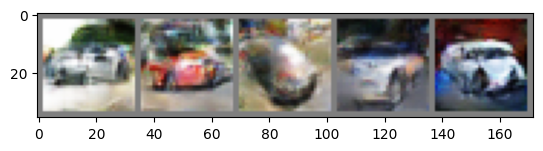

EPOCH 600: BATCH: 78, discrim_loss: 0.03916843980550766, generator_loss: 7.9743781089782715
npimg.shape: (3, 36, 172)


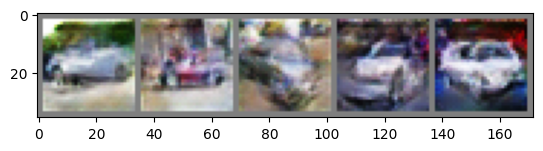

EPOCH 800: BATCH: 78, discrim_loss: 0.03410876542329788, generator_loss: 5.403860092163086
npimg.shape: (3, 36, 172)


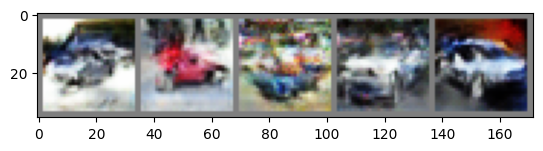

In [36]:
from tqdm.auto import tqdm

g_losses = []
d_losses = []

testing_random_latent = torch.zeros(5, opt.latent_dim, 1, 1, requires_grad=False).normal_(0, 1).to(device)

for epoch in tqdm(range(opt.n_epochs)):

    for batch_index, (batch, _) in enumerate(batch_iterator):

        ############################################
        # target 생성
        ############################################
        real = torch.ones(batch.size(0), 1, 1, 1, requires_grad=False).to(device)
        fake = torch.zeros(batch.size(0), 1, 1, 1, requires_grad=False).to(device)

        ############################################
        # features 생성
        ############################################
        imgs_real = batch.to(device)
        noise = torch.zeros(batch.size(0), opt.latent_dim, 1, 1, requires_grad=False).normal_(0, 1).to(device)
        imgs_fake = generator(noise)

        ############################################
        # == Discriminator update == #
        ############################################
        # 모델 학습
        d_real_pred = discriminator(imgs_real)
        d_fake_pred = discriminator(imgs_fake)

        # loss 계산
        d_loss = gan_loss(d_real_pred, real) + \
                 gan_loss(d_fake_pred, fake)

        # 역전파
        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        ############################################
        # == Generator update == #
        ############################################
        # input data
        noise = torch.zeros(batch.size(0), opt.latent_dim, 1, 1, requires_grad=False).normal_(0, 1).to(device)

        # 모델 학습
        imgs_fake = generator(noise)

        # loss 계산
        d_fake_pred = discriminator(imgs_fake)
        g_loss = gan_loss(d_fake_pred, real)

        # 역전파
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        ###################################################
        # == loss update == #
        ###################################################
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    ###################################################
    # epoch 40번에 한번씩 가짜 이미지를 print
    ###################################################
    if epoch % 200 == 0:
        print("EPOCH {}: BATCH: {}, discrim_loss: {}, generator_loss: {}".format(epoch, batch_index, d_loss, g_loss))
        with torch.no_grad():
            testing_fake_images = generator(testing_random_latent)
            testing_fake_images = testing_fake_images.reshape(5, 3, 32, 32)
            imshow(torchvision.utils.make_grid(testing_fake_images.cpu()))


# [InfoGAN - 2016](https://github.com/ozanciga/gans-with-pytorch/blob/master/infogan/infogan.py)

## Information Maximizing GAN
기존 GAN의 생성 모델의 input의 latent variable z 하나인 것에 비해 InfoGAN은 code라는 의미의 latent variable c가 추가되어 G(z,c) 형태로 만들어집니다.   
- z: 더이상 압축할 수 없는 noise.   
- c: latent code라고 부르며 data distribution의 semantic feature를 표현  

여기서 z와 c의 Mutual Information(MI)를 최대화시켜, 기존 GAN과는 차별화된 모습을 보여줍니다.



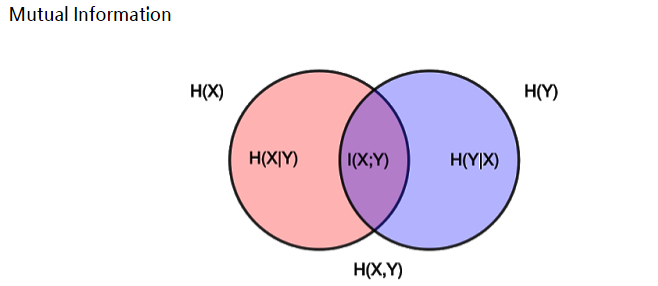

### Mutual Information for Inducing Latent Codes
기존의 GAN모델이 entangled(얽혀있는) representation들을 학습해왔는데, InfoGAN에서는 disentangled(엉킨것이 풀어진) representation들을 학습하는 방법을 제시한다. 이게 무슨 말 이냐면 , 일반적인 GAN은 input에서 noise에 대한 아무런 제약이 없으므로 noise에 대한 정보를 알 수 없다. 즉, noise input 에서 어느부분이 어떤 representation을 조절하는지를 알기 힘들다. 하지만 이것을 disentangle하게 , 다시말하면 해석가능하게(어느부분이 의미를 가지도록) 만들어 핵심적인 representation을 학습 할 수 있게 해준다는 것 이다.

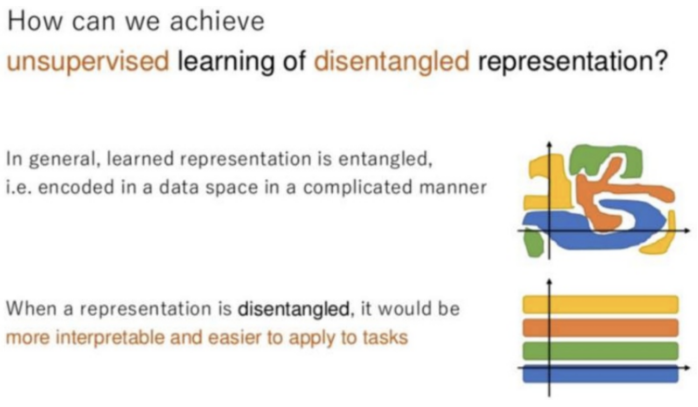

## InfoGAN 모델 구조

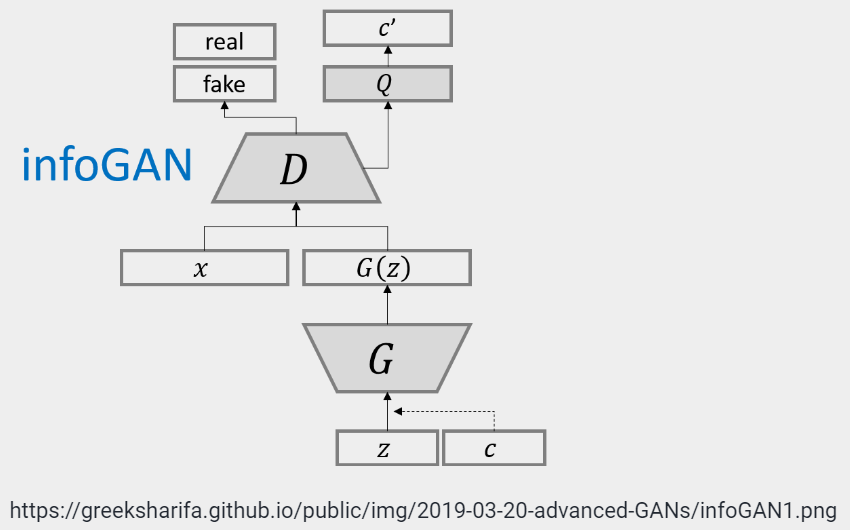

## Model

In [ ]:
opt = easydict.EasyDict()
opt.n_epochs = 50  #200
opt.batch_size = 64
opt.d_lr = 0.0002
opt.g_lr = 0.001
opt.b1 = 0.5
opt.b2 = 0.999
opt.latent_dim = 74
opt.lambda_c = 0.1
opt.img_size = 28
opt.channels = 1
opt.n_classes = 10
opt.sample_interval = 64

In [ ]:
cuda = torch.cuda.is_available()
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor
LongTensor = torch.cuda.LongTensor if cuda else torch.LongTensor

In [ ]:
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

In [ ]:
def to_categorical(y):
    """ 1-hot encodes a tensor """
    # return Tensor(torch.eye(10)[y])
    y = LongTensor(y).view(-1, 1)
    y_onehot = Tensor(y.size(0), 10)
    y_onehot.zero_()
    y_onehot.scatter_(1, y, 1)
    return y_onehot

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        def convlayer(n_input, n_output, k_size=5, stride=2, padding=0, output_padding=0):
            block = [
                nn.ConvTranspose2d(n_input, n_output, kernel_size=k_size, stride=stride, padding=padding, bias=False, output_padding=output_padding),
                nn.BatchNorm2d(n_output),
                nn.ReLU(inplace=True),
            ]
            return block

        self.conv_block = nn.Sequential(
            *convlayer(opt.latent_dim, 1024, 1, 1),                     # 1024 x 1 x 1
            *convlayer(1024, 128, 7, 1, 0),                             # 128 x 7 x 7
            *convlayer(128, 64, 4, 2, 1),                               # 64 x 14 x 14
            nn.ConvTranspose2d(64, opt.channels, 4, 2, 1, bias=False),  # 1 x 28 x 28
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(-1, opt.latent_dim, 1, 1)
        img = self.conv_block(z)
        return img

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        def convlayer(n_input, n_output, k_size=4, stride=2, padding=0, normalize=True):
            block = [nn.Conv2d(n_input, n_output, kernel_size=k_size, stride=stride, padding=padding, bias=False)]
            if normalize:
                block.append(nn.BatchNorm2d(n_output))
            block.append(nn.LeakyReLU(0.1, inplace=True))
            return block

        self.model = nn.Sequential(                                     # 1 x 28 x 28
            *convlayer(opt.channels, 64, 4, 2, 1, normalize=False),     # 64 x 14 x 14
            *convlayer(64, 128, 4, 2, 1),                               # 128 x 7 x 7
            *convlayer(128, 1024, 7, 1, 0),                             # 1024 x 1 x 1
        )

        # Regular probability of pertaining to real distribution.
        self.d_head = nn.Sequential(
            nn.Linear(1024, 1),
            nn.Sigmoid(),
        )

        # Continuous.
        self.q_head_C = nn.Sequential(
            nn.Linear(1024, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 2)
        )

        # Discrete (digits).
        self.q_head_D = nn.Sequential(
            nn.Linear(1024, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 10),
            nn.Softmax(dim=1)
        )

    def forward(self, img):
        conv_out = self.model(img)
        conv_out = conv_out.squeeze(dim=3).squeeze(dim=2)
        prob = self.d_head(conv_out)
        # Continuous output parameters.
        q = self.q_head_C(conv_out)
        # mu, std = self.q_head_C_mu(q), self.q_head_C_std(q).exp()
        # Discrete outputs.
        digit_probs = self.q_head_D(conv_out)

        return prob, digit_probs, q # mu, std

In [ ]:
class GaussianLoss():  # loss pertaining to q(c|x)
    def __call__(self, mu_, std_, x):
        eps = 1e-6
        epsilon = ((x - mu_) / (std_ + eps)) ** 2
        loss = (std_.log() + 0.5 * epsilon)
        loss = torch.mean(loss)

        return loss

## MNIST Data

In [ ]:
def mnist_data():
    compose = transforms.Compose(
        [transforms.Resize(opt.img_size),
         transforms.ToTensor(),
         transforms.Normalize((0.5), (0.5))
         ])
    output_dir = './data/mnist'
    return datasets.MNIST(root=output_dir, train=True,
                          transform=compose, download=True)

In [ ]:
mnist = mnist_data()
batch_iterator = DataLoader(mnist, shuffle=True, batch_size=opt.batch_size) # List, NCHW format.

## Train

In [ ]:
gan_loss = nn.BCELoss()
discrete_loss = nn.NLLLoss()
continuous_loss = nn.MSELoss() # GaussianLoss()

In [ ]:
generator = Generator()
discriminator = Discriminator()

In [ ]:
optimizer_D = optim.Adam(discriminator.parameters(), lr=opt.d_lr, betas=(opt.b1, opt.b2))
optimizer_G = optim.Adam(generator.parameters(), lr=opt.g_lr, betas=(opt.b1, opt.b2))

In [ ]:
if cuda:
    generator = generator.cuda()
    discriminator = discriminator.cuda()
    gan_loss = gan_loss.cuda()
    discrete_loss = discrete_loss.cuda()
    continuous_loss = continuous_loss.cuda()

generator.apply(weights_init_normal)
discriminator.apply(weights_init_normal)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.1, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.1, inplace=True)
    (5): Conv2d(128, 1024, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (6): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.1, inplace=True)
  )
  (d_head): Sequential(
    (0): Linear(in_features=1024, out_features=1, bias=True)
    (1): Sigmoid()
  )
  (q_head_C): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Linear(in_features=12

In [ ]:
noise = Variable(Tensor(100, opt.latent_dim - 10 - 2).normal_(0, 1), requires_grad=False)
digits = Variable(to_categorical([i for i in range(10) for j in range(10)]), requires_grad=False)

c1 = Variable(Tensor(torch.linspace(-1, 1, 10).repeat(10,).data.numpy()).unsqueeze_(1), requires_grad=False)
c2 = Variable(Tensor(100, 1).fill_(0), requires_grad=False)

z_fixed0 = torch.cat((noise, digits, c2, c2), dim=-1)
z_fixed1 = torch.cat((noise, digits, c1, c2), dim=-1)
z_fixed2 = torch.cat((noise, digits, c2, c1), dim=-1)

<ipython-input-56-9ab61335b4bc>:1: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:78.)
  noise = Variable(Tensor(100, opt.latent_dim - 10 - 2).normal_(0, 1), requires_grad=False)


  0%|          | 0/50 [00:00<?, ?it/s]

EPOCH 0: BATCH: 937, discrim_loss: 0.6661033034324646, generator_loss: 0.7375150322914124


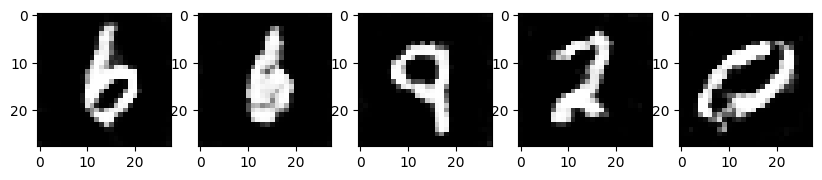

EPOCH 10: BATCH: 937, discrim_loss: 0.4607691168785095, generator_loss: 1.1485071182250977


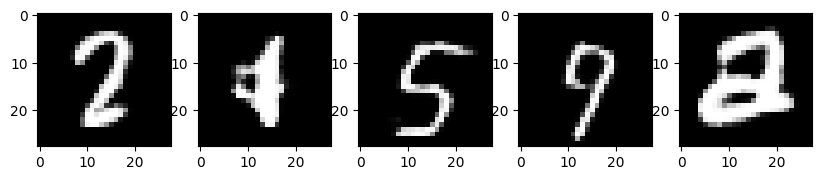

KeyboardInterrupt: 

In [ ]:
from tqdm.auto import tqdm

for epoch in tqdm(range(opt.n_epochs)):
    for batch_index, (batch, _) in enumerate(batch_iterator):

        real = Variable(Tensor(batch.size(0), 1).fill_(1.0), requires_grad=False)
        fake = Variable(Tensor(batch.size(0), 1).fill_(0.0), requires_grad=False)

        imgs_real = Variable(batch.type(Tensor))


        # == Discriminator update == #
        optimizer_D.zero_grad()

        noise = Variable(Tensor(batch.size(0), opt.latent_dim - 10 - 2).normal_(0, 1))
        digits = to_categorical(list(torch.randint(0, 9, (batch.size(0), ))))
        cis = Variable(Tensor(batch.size(0), 2).uniform_(-1, 1))  # c_i's (continuous variables)

        z = torch.cat((noise, digits, cis), dim=1)  # [62 noise parameters | 10 one-hot encoding params | c_1 | c_2]

        imgs_fake = generator(z)

        prob_real, _, _ = discriminator(imgs_real)
        prob_fake, _, _ = discriminator(imgs_fake.data)

        d_loss = 0.5*gan_loss(prob_real, real) + 0.5*gan_loss(prob_fake, fake)

        d_loss.backward()
        optimizer_D.step()

        # == Generator update == #
        optimizer_G.zero_grad()

        d_labels = torch.randint(0, 9, (batch.size(0), )).data.numpy()   # Discrete labels (0..9).
        c_labels = Variable(Tensor(batch.size(0), 2).uniform_(-1, 1), requires_grad=False)
        d_targets = Variable(LongTensor(d_labels), requires_grad=False)   # Discrete targets.

        noise = Variable(Tensor(batch.size(0), opt.latent_dim - 10 - 2).normal_(0, 1))
        digits = Variable(to_categorical(d_labels))

        z = torch.cat((noise, digits, c_labels), dim=1)  # [62 noise parameters | 10 one-hot encoding params | c_1 | c_2]

        imgs_fake = generator(z)
        prob_fake, logits, q = discriminator(imgs_fake)

        # Mutual information added loss of InfoGAN.
        g_vanilla_loss = gan_loss(prob_fake, real)
        g_discrete_loss = discrete_loss(logits, d_targets)  # labels, logits.. takes me back... to the horrific tensorflow days.
        g_continuous_loss = continuous_loss(q, c_labels)
        g_loss = g_vanilla_loss + g_discrete_loss + opt.lambda_c*g_continuous_loss

        g_loss.backward()
        optimizer_G.step()

    if epoch % 10 == 0:
        print("EPOCH {}: BATCH: {}, discrim_loss: {}, generator_loss: {}".format(epoch, batch_index, d_loss, g_loss))
        z = torch.cat((noise, digits, c_labels), dim=1)
        with torch.no_grad():
            testing_fake_images = generator(z[:5])
            testing_fake_images = testing_fake_images.reshape(5, 28, 28).cpu().numpy()

            plt.figure(figsize=(10, 5))
            # plt.title("GENERATED IMAGE, EPOCH {}".format(epoch))
            for i in range(5):
                plt.subplot(int('15{}'.format(i+1)))
                plt.imshow(testing_fake_images[i], cmap='gray')
            plt.show()

# [WGAN-GP - 2017](https://github.com/ozanciga/gans-with-pytorch/blob/master/wgan-gp/wgan_gp.py)

## Wasserstein GAN(Gradient Penalty)

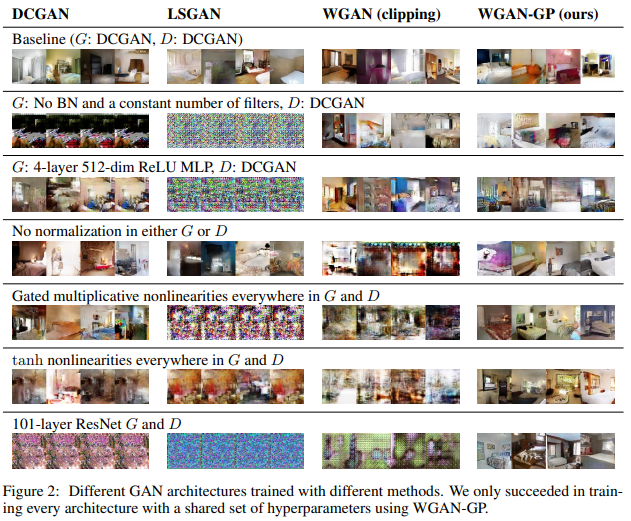

### DCGAN의 한계와 차이점
DCGAN 모델에서 생성자를 판별자의 결과만으로 업데이트 되었기 때문에, 판별자에 비하면 학습이 잘 안될 수 밖에 없다. 그래서 아래와 같이 생성자는 판별자를 잘 속이는 일부 샘플(mode)을 발견하면 그것만 계속 만들어낸다.

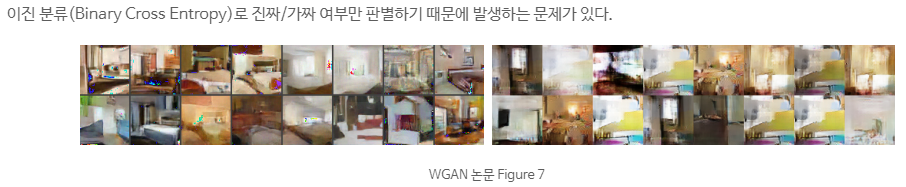

### 새로운 손실 함수

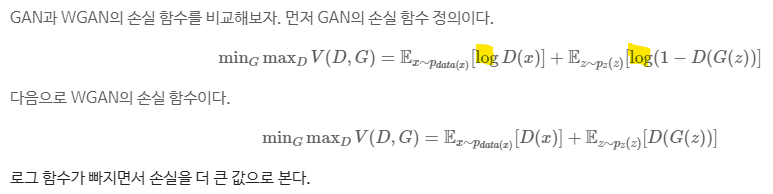

### Gradient Penalty
- 판별자의 마지막 레이어였던 sigmoid 활성화 함수를 제거해서 예측 값의 범위가 $[0,1]$에서 $[-\infty, \infty]$가 된다.
- 이런 이유로 WGAN의 판별자는 0/1 판별이 아니라 점수를 주다 보니 비평자(Critic)라고 불린다.
- 비평자의 결과가 $[-\infty, \infty]$ 사이의 값이다 보니, 사실상 손실이 무한으로 나올 수 있다. 이런 문제를 해결한 방법이 Gradient Penalty이다.

첫번째 이미지는 Gradient Penalty를 적용하지 않았을 때, 이미지이며, 두번째 이미지는 적용했을 때의 이미지이다.

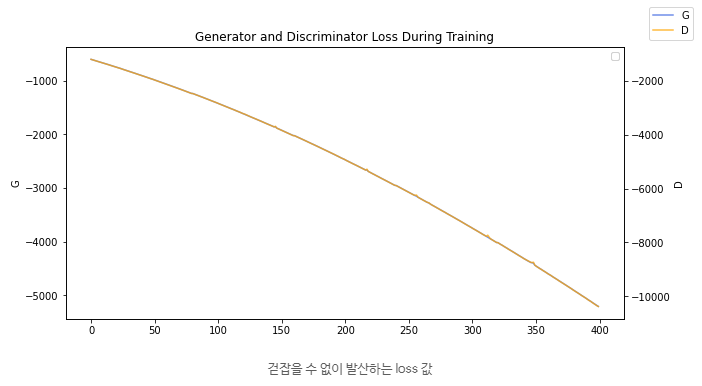

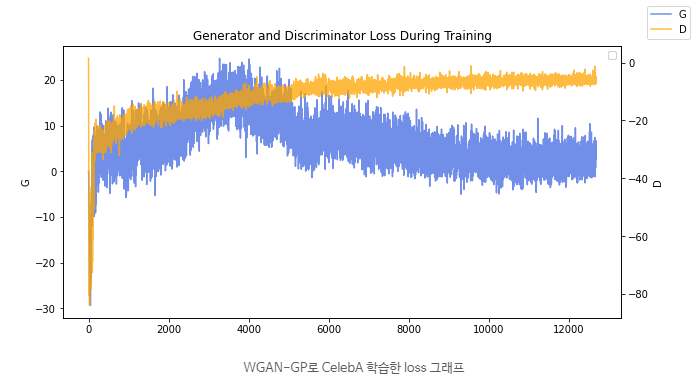

## WGAN-GP 모델 구조

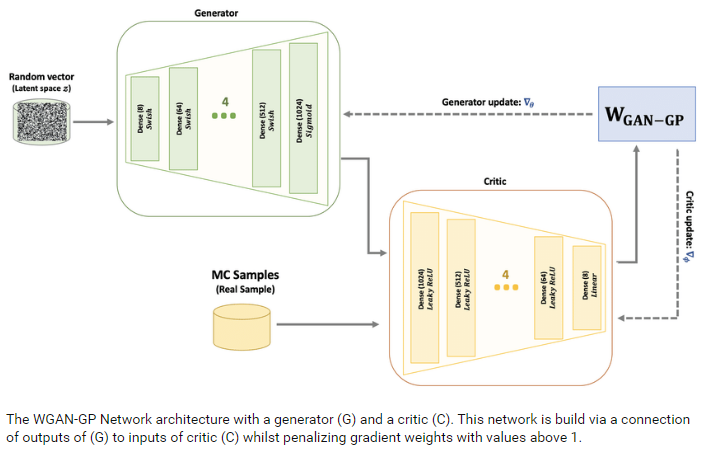

## Model

In [ ]:
opt = easydict.EasyDict()
opt.n_epochs = 100
opt.batch_size = 64
opt.alpha = 0.0001
opt.b1 = 0.5
opt.b2 = 0.9
opt.n_critic = 5
opt.lambda_1 = 10
opt.img_size = 32
opt.channels = 3
opt.n_classes = 10
opt.sample_interval = 256

In [ ]:
img_dims = (opt.channels, opt.img_size, opt.img_size)
n_features = opt.channels * opt.img_size * opt.img_size

In [ ]:
def init_weights(m):
    if type(m) == nn.ConvTranspose2d:
        torch.nn.init.kaiming_normal(m.weight, mode='fan_out', nonlinearity='relu')
    elif type(m) == nn.Conv2d:
        torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='leaky_relu')

In [ ]:
class MeanPoolConv(nn.Module):
    def __init__(self, n_input, n_output, k_size):
        super(MeanPoolConv, self).__init__()
        conv1 = nn.Conv2d(n_input, n_output, k_size, stride=1, padding=(k_size-1)//2, bias=True)
        self.model = nn.Sequential(conv1)
    def forward(self, x):
        out = (x[:,:,::2,::2] + x[:,:,1::2,::2] + x[:,:,::2,1::2] + x[:,:,1::2,1::2]) / 4.0
        out = self.model(out)
        return out

In [ ]:
class ConvMeanPool(nn.Module):
    def __init__(self, n_input, n_output, k_size):
        super(ConvMeanPool, self).__init__()
        conv1 = nn.Conv2d(n_input, n_output, k_size, stride=1, padding=(k_size-1)//2, bias=True)
        self.model = nn.Sequential(conv1)
    def forward(self, x):
        out = self.model(x)
        out = (out[:,:,::2,::2] + out[:,:,1::2,::2] + out[:,:,::2,1::2] + out[:,:,1::2,1::2]) / 4.0
        return out

In [ ]:
class UpsampleConv(nn.Module):
    def __init__(self, n_input, n_output, k_size):
        super(UpsampleConv, self).__init__()

        self.model = nn.Sequential(
            nn.PixelShuffle(2),
            nn.Conv2d(n_input, n_output, k_size, stride=1, padding=(k_size-1)//2, bias=True)
        )
    def forward(self, x):
        x = x.repeat((1, 4, 1, 1)) # Weird concat of WGAN-GPs upsampling process.
        out = self.model(x)
        return out

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, n_input, n_output, k_size, resample='up', bn=True, spatial_dim=None):
        super(ResidualBlock, self).__init__()

        self.resample = resample

        if resample == 'up':
            self.conv1 = UpsampleConv(n_input, n_output, k_size)
            self.conv2 = nn.Conv2d(n_output, n_output, k_size, padding=(k_size-1)//2)
            self.conv_shortcut = UpsampleConv(n_input, n_output, k_size)
            self.out_dim = n_output
        elif resample == 'down':
            self.conv1 = nn.Conv2d(n_input, n_input, k_size, padding=(k_size-1)//2)
            self.conv2 = ConvMeanPool(n_input, n_output, k_size)
            self.conv_shortcut = ConvMeanPool(n_input, n_output, k_size)
            self.out_dim = n_output
            self.ln_dims = [n_input, spatial_dim, spatial_dim] # Define the dimensions for layer normalization.
        else:
            self.conv1 = nn.Conv2d(n_input, n_input, k_size, padding=(k_size-1)//2)
            self.conv2 = nn.Conv2d(n_input, n_input, k_size, padding=(k_size-1)//2)
            self.conv_shortcut = None # Identity
            self.out_dim = n_input
            self.ln_dims = [n_input, spatial_dim, spatial_dim]

        self.model = nn.Sequential(
            nn.BatchNorm2d(n_input) if bn else nn.LayerNorm(self.ln_dims),
            nn.ReLU(inplace=True),
            self.conv1,
            nn.BatchNorm2d(self.out_dim) if bn else nn.LayerNorm(self.ln_dims),
            nn.ReLU(inplace=True),
            self.conv2,
        )

    def forward(self, x):
        if self.conv_shortcut is None:
            return x + self.model(x)
        else:
            return self.conv_shortcut(x) + self.model(x)

In [ ]:
class DiscBlock1(nn.Module):
    def __init__(self, n_output):
        super(DiscBlock1, self).__init__()

        self.conv1 = nn.Conv2d(3, n_output, 3, padding=(3-1)//2)
        self.conv2 = ConvMeanPool(n_output, n_output, 1)
        self.conv_shortcut = MeanPoolConv(3, n_output, 1)

        self.model = nn.Sequential(
            self.conv1,
            nn.ReLU(inplace=True),
            self.conv2
        )

    def forward(self, x):
        return self.conv_shortcut(x) + self.model(x)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(                     # 128 x 1 x 1
            nn.ConvTranspose2d(128, 128, 4, 1, 0),      # 128 x 4 x 4
            ResidualBlock(128, 128, 3, resample='up'),  # 128 x 8 x 8
            ResidualBlock(128, 128, 3, resample='up'),  # 128 x 16 x 16
            ResidualBlock(128, 128, 3, resample='up'),  # 128 x 32 x 32
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 3, 3, padding=(3-1)//2),     # 3 x 32 x 32
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        n_output = 128
        '''
        This is a parameter but since we experiment with a single size
        of 3 x 32 x 32 images, it is hardcoded here.
        '''

        self.DiscBlock1 = DiscBlock1(n_output)                      # 128 x 16 x 16

        self.model = nn.Sequential(
            ResidualBlock(n_output, n_output, 3, resample='down', bn=False, spatial_dim=16),  # 128 x 8 x 8
            ResidualBlock(n_output, n_output, 3, resample=None, bn=False, spatial_dim=8),    # 128 x 8 x 8
            ResidualBlock(n_output, n_output, 3, resample=None, bn=False, spatial_dim=8),    # 128 x 8 x 8
            nn.ReLU(inplace=True),
        )
        self.l1 = nn.Sequential(nn.Linear(128, 1))                  # 128 x 1

    def forward(self, x):
        # x = x.view(-1, 3, 32, 32)
        y = self.DiscBlock1(x)
        y = self.model(y)
        y = y.view(x.size(0), 128, -1)
        y = y.mean(dim=2)
        out = self.l1(y).unsqueeze_(1).unsqueeze_(2) # or *.view(x.size(0), 128, 1, 1, 1)
        return out

## CIFAR10 Data

In [ ]:
def load_cifar10(img_size):
    compose = transforms.Compose(
        [transforms.Resize(img_size),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
         ])
    output_dir = './data/cifar10'
    cifar = datasets.CIFAR10(root=output_dir, download=True, train=True,
                             transform=compose)
    return cifar

In [ ]:
cifar = load_cifar10(opt.img_size)
batch_iterator = DataLoader(cifar, shuffle=True, batch_size=opt.batch_size) # List, NCHW format.

Files already downloaded and verified


## Train

In [ ]:
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    print(f'npimg.shape: {npimg.shape}')
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [ ]:
cuda = torch.cuda.is_available()
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor
gan_loss = nn.BCELoss()

generator = Generator()
discriminator = Discriminator()

optimizer_D = optim.Adam(discriminator.parameters(), lr=opt.alpha, betas=(opt.b1, opt.b2))
optimizer_G = optim.Adam(generator.parameters(), lr=opt.alpha, betas=(opt.b1, opt.b2))

In [ ]:
if cuda:
    generator = generator.cuda()
    discriminator = discriminator.cuda()

  0%|          | 0/100 [00:00<?, ?it/s]

EPOCH 0: BATCH: 781, discrim_loss: -2.630903720855713, generator_loss: -2.186779260635376
npimg.shape: (3, 36, 172)


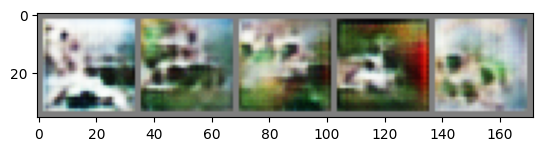

KeyboardInterrupt: 

In [ ]:
from tqdm.auto import tqdm

g_losses = []
d_losses = []

testing_random_latent = torch.zeros(5, 128, 1, 1, requires_grad=False).normal_(0, 1).to(device)

for epoch in tqdm(range(opt.n_epochs)):

    for batch_index, (batch, _) in enumerate(batch_iterator):
        # == Discriminator update == #
        for iter in range(opt.n_critic):
            # Sample real and fake images, using notation in paper.
            x = Variable(batch.type(Tensor))
            noise = Variable(Tensor(batch.size(0), 128, 1, 1).normal_(0, 1))
            x_tilde = Variable(generator(noise), requires_grad=True)

            epsilon = Variable(Tensor(batch.size(0), 1, 1, 1).uniform_(0, 1))

            x_hat = epsilon*x + (1 - epsilon)*x_tilde
            x_hat = torch.autograd.Variable(x_hat, requires_grad=True)

            # Put the interpolated data through critic.
            dw_x = discriminator(x_hat)
            # A great exercise on learning how the autograd.grad works!
            grad_x = torch.autograd.grad(outputs=dw_x, inputs=x_hat,
                                         grad_outputs=Variable(Tensor(batch.size(0), 1, 1, 1).fill_(1.0), requires_grad=False),
                                         create_graph=True, retain_graph=True, only_inputs=True)
            grad_x = grad_x[0].view(batch.size(0), -1)
            grad_x = grad_x.norm(p=2, dim=1) # My naming is inaccurate, this is the 2-norm of grad(D_w(x_hat))

            # Update discriminator (or critic, since we don't output probabilities anymore).
            optimizer_D.zero_grad()

            # WGAN-GP loss, defined properly as a loss unlike the WGAN paper.
            d_loss = torch.mean(discriminator(x_tilde)) - torch.mean(discriminator(x)) + opt.lambda_1*torch.mean((grad_x - 1)**2)
            # d_loss = torch.mean(d_loss) # there's a reason for why this shouldn't be done this way :)

            d_loss.backward()
            optimizer_D.step()

        # == Generator update == #
        noise = Variable(Tensor(batch.size(0), 128, 1, 1).normal_(0, 1))
        imgs_fake = generator(noise)

        optimizer_G.zero_grad()

        g_loss = -torch.mean(discriminator(imgs_fake))

        g_loss.backward()
        optimizer_G.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    if epoch % 10 == 0:
        print("EPOCH {}: BATCH: {}, discrim_loss: {}, generator_loss: {}".format(epoch, batch_index, d_loss, g_loss))
        with torch.no_grad():
            testing_fake_images = generator(testing_random_latent)
            testing_fake_images = testing_fake_images.reshape(5, 3, 32, 32)
            imshow(torchvision.utils.make_grid(testing_fake_images.cpu()))

# [pix2pix - 2017](https://velog.io/@wilko97/%EB%85%BC%EB%AC%B8%EC%8B%A4%EC%8A%B5-Pix2Pix)
- Pix2Pix는 image를 image로 변환하도록 generator을 학습합니다.
- 예를 들어, generator의 입력값으로 스케치 그림을 입력하면 완성된 그림이 나오도록 학습할 수 있습니다.
- 기존 GAN과 비교하여 설명하자면, Pix2Pix는 기존 GAN의 noise 대신에 스케치 그림을 입력하여 학습을 하는 것입니다.

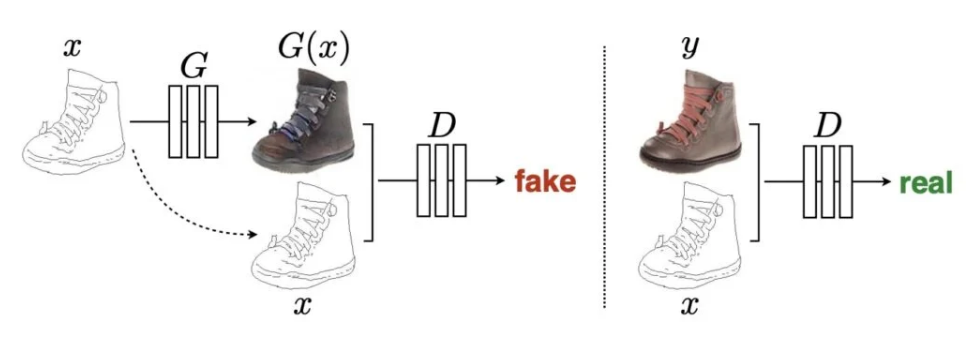

In [ ]:
import os
import glob
import numpy as np
import datetime
import matplotlib.pyplot as plt
from PIL import Image

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.utils import save_image
import torch.nn as nn
import torch.nn.functional as F
import torch
import torchvision
from torch.autograd import Variable

In [ ]:
batch_size = 12
img_height = 256
img_width = 256

## [Download Data](https://www.kaggle.com/datasets/elibooklover/victorian400/data)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("elibooklover/victorian400")

print("Path to dataset files:", path)

In [ ]:
import os

# 폴더 안을 더 탐색
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))
        break

## Dataset

In [ ]:
class VictorianDataset(Dataset):
    def __init__(self, root, color_transforms_=None, gray_transforms_=None):

        self.color_transforms = transforms.Compose(color_transforms_)
        self.gray_transforms = transforms.Compose(gray_transforms_)
        self.gray_files = sorted(glob.glob(os.path.join(root, 'gray') + "/*.*"))
        self.color_files = sorted(glob.glob(os.path.join(root, 'resized') + "/*.*"))

    def __getitem__(self, index):
        gray_img = Image.open(self.gray_files[index % len(self.gray_files)]).convert("RGB")
        color_img = Image.open(self.color_files[index % len(self.color_files)]).convert("RGB")

        gray_img = self.gray_transforms(gray_img)
        color_img = self.color_transforms(color_img)

        return {"A": gray_img, "B": color_img}

    def __len__(self):
        return len(self.gray_files)

In [ ]:
color_mean = [0.58090717, 0.52688643, 0.45678478]
color_std = [0.25644188, 0.25482641, 0.24456465]
gray_mean = [0.5350533, 0.5350533, 0.5350533]
gray_std = [0.25051587, 0.25051587, 0.25051587]

color_transforms_ = [
    transforms.ToTensor(),
    transforms.Normalize(mean=color_mean, std=color_std),
]

gray_transforms_ = [
    transforms.ToTensor(),
    transforms.Normalize(mean=gray_mean, std=gray_std),
]

## DataLoader

In [ ]:
train_loader  = DataLoader(
    VictorianDataset(path, color_transforms_=color_transforms_, gray_transforms_=gray_transforms_),
    batch_size=batch_size,
    shuffle=True
)

In [ ]:
def reNormalize(img, mean, std):
    img = img.numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = img.clip(0, 1)
    return img

In [ ]:
fig = plt.figure(figsize=(10, 5))
rows = 1
cols = 2

for X in train_loader :

    print(X['A'].shape, X['B'].shape)
    ax1 = fig.add_subplot(rows, cols, 1)
    ax1.imshow(reNormalize(X["A"][0], gray_mean, gray_std))
    ax1.set_title('gray img')

    ax2 = fig.add_subplot(rows, cols, 2)
    ax2.imshow(reNormalize(X["B"][0], color_mean, color_std))
    ax2.set_title('color img')

    plt.show()
    break

## [Model](https://developers.arcgis.com/python/guide/how-pix2pix-works/)
- pix2pix의 특징은 일반적인 인코더-디코더(Encoder-Decoder)보다는 U-NET을 사용합니다.
- U-NET의 특징은 일반적인 인코더-디코더와 달리 스킵 커넥션 (Skip Connections)이 있어, 인코더 레이어와 디코더 레이어 간의 연결을 보다 로컬라이징(localization)을 잘 해주는 특징이 있습니다.
- 예를 들어, 첫 인코더 레이어 크기가 256 x 256 x 3이라면, 마지막 디코더 레이어 크기도 똑같이 256 x 256 x 3이게 됩니다.
- 이렇게 같은 크기의 인코더-디코더 레이어가 결합하여, 보다 효과적이고 빠른 성능을 발휘할 수 있게 하는게 U-NET의 특징입니다.

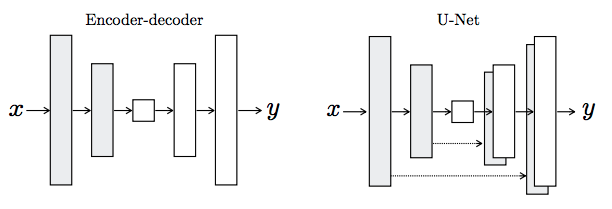

In [ ]:
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm2d") != -1:
        torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(m.bias.data, 0.0)

# U-NET 생성

class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True, dropout=0.0):
        super(UNetDown, self).__init__()
        layers = [nn.Conv2d(in_size, out_size, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_size))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UNetUp(nn.Module):
    def __init__(self, in_size, out_size, dropout=0.0):
        super(UNetUp, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_size, out_size, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_size),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))

        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)

        return x


In [ ]:
class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(GeneratorUNet, self).__init__()

        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False, dropout=0.5)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        # U-Net generator with skip connections from encoder to decoder
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)
        u1 = self.up1(d8, d7)
        u2 = self.up2(u1, d6)
        u3 = self.up3(u2, d5)
        u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3)
        u6 = self.up6(u5, d2)
        u7 = self.up7(u6, d1)

        return self.final(u7)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super(Discriminator, self).__init__()

        def discriminator_block(in_filters, out_filters, normalization=True):
            """Returns downsampling layers of each discriminator block"""
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalization:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(in_channels * 2, 64, normalization=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1, bias=False)
        )

    def forward(self, img_A, img_B):
        # Concatenate image and condition image by channels to produce input
        img_input = torch.cat((img_A, img_B), 1)
        return self.model(img_input)

In [ ]:
GeneratorUNet().apply(weights_init_normal)

In [ ]:
Discriminator().apply(weights_init_normal)

## Training

In [ ]:
n_epochs = 100
dataset_name = "Victorian400"
lr = 0.0002
b1 = 0.5                    # adam: decay of first order momentum of gradient
b2 = 0.999                  # adam: decay of first order momentum of gradient
decay_epoch = 100           # epoch from which to start lr decay
#n_cpu = 8                   # number of cpu threads to use during batch generation
channels = 3                # number of image channels
checkpoint_interval = 20    # interval between model checkpoints

In [ ]:
os.makedirs("images/%s/val" % dataset_name, exist_ok=True)
os.makedirs("images/%s/test" % dataset_name, exist_ok=True)
os.makedirs("saved_models/%s" % dataset_name, exist_ok=True)

# Loss functions
criterion_GAN = torch.nn.MSELoss()
criterion_pixelwise = torch.nn.L1Loss()

# Loss weight of L1 pixel-wise loss between translated image and real image
lambda_pixel = 100

# Calculate output of image discriminator (PatchGAN)
patch = (1, img_height // 2 ** 4, img_width // 2 ** 4)

# Initialize generator and discriminator
generator = GeneratorUNet()
discriminator = Discriminator()

cuda = True if torch.cuda.is_available() else False

if cuda:
    generator = generator.cuda()
    discriminator = discriminator.cuda()
    criterion_GAN.cuda()
    criterion_pixelwise.cuda()

# Optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

# Tensor type
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

In [ ]:
train_loader  = DataLoader(
    VictorianDataset(path, color_transforms_=color_transforms_, gray_transforms_=gray_transforms_),
    batch_size=batch_size,
    shuffle=True
)

In [ ]:
def sample_images(epoch, loader, mode):
    imgs = next(iter(loader))
    gray = Variable(imgs["A"].type(Tensor))
    color = Variable(imgs["B"].type(Tensor))
    output = generator(gray)

    gray_img = torchvision.utils.make_grid(gray.data, nrow=6)
    color_img = torchvision.utils.make_grid(color.data, nrow=6)
    output_img = torchvision.utils.make_grid(output.data, nrow=6)

    rows = 3
    cols = 1

    ax1 = fig.add_subplot(rows, cols, 1)
    ax1.imshow(reNormalize(gray_img.cpu(), gray_mean, gray_std))
    ax1.set_title('gray')

    ax2 = fig.add_subplot(rows, cols, 2)
    ax2.imshow(reNormalize(color_img.cpu(), color_mean, color_std))
    ax2.set_title('color')

    ax3 = fig.add_subplot(rows, cols, 3)
    ax3.imshow(reNormalize(output_img.cpu(), color_mean, color_std))
    ax3.set_title('output')

    plt.show()
    fig.savefig("images/%s/%s/epoch_%s.png" % (dataset_name, mode, epoch), pad_inches=0)

In [ ]:
from tqdm.auto import tqdm
# ----------
#  Training
# ----------

for epoch in tqdm(range(1, n_epochs+1)):
    start_time = datetime.datetime.now()
    for i, batch in enumerate(train_loader):

        # Model inputs
        gray = Variable(batch["A"].type(Tensor))
        color = Variable(batch["B"].type(Tensor))

        # Adversarial ground truths
        valid = Variable(Tensor(np.ones((gray.size(0), *patch))), requires_grad=False)
        fake = Variable(Tensor(np.zeros((gray.size(0), *patch))), requires_grad=False)

        # ------------------
        #  Train Generators
        # ------------------

        optimizer_G.zero_grad()

        # GAN loss
        output = generator(gray)
        pred_fake = discriminator(output, gray)
        loss_GAN = criterion_GAN(pred_fake, valid)
        # Pixel-wise loss
        loss_pixel = criterion_pixelwise(output, color)

        # Total loss
        loss_G = loss_GAN + lambda_pixel * loss_pixel

        loss_G.backward()

        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Real loss
        pred_real = discriminator(color, gray)
        loss_real = criterion_GAN(pred_real, valid)

        # Fake loss
        pred_fake = discriminator(output.detach(), gray)
        loss_fake = criterion_GAN(pred_fake, fake)

        # Total loss
        loss_D = 0.5 * (loss_real + loss_fake)

        loss_D.backward()
        optimizer_D.step()

        epoch_time = datetime.datetime.now() - start_time

    if (epoch) % checkpoint_interval == 0:
        fig = plt.figure(figsize=(18, 18))
        sample_images(epoch, train_loader, 'val')

        torch.save(generator.state_dict(), "saved_models/%s/generator_%d.pth" % (dataset_name, epoch))
        torch.save(discriminator.state_dict(), "saved_models/%s/discriminator_%d.pth" % (dataset_name, epoch))

        print("[Epoch %d/%d] [Batch %d/%d] [D loss: %f] [G loss: %f, pixel: %f, adv: %f] ETA: %s" % (epoch,
                                                                                                    n_epochs,
                                                                                                    i+1,
                                                                                                    len(train_loader),
                                                                                                    loss_D.item(),
                                                                                                    loss_G.item(),
                                                                                                    loss_pixel.item(),
                                                                                                    loss_GAN.item(),
                                                                                                    epoch_time))


# 참고 파일들
- https://github.com/eriklindernoren/PyTorch-GAN
- https://github.com/ozanciga/gans-with-pytorch